# IE6600 Computation and Visualization for Analytics

### Interactive Data Visualization - Part 1
#### -- STUDENT VERSION --


### Plotly

In [1]:
import sys
!{sys.executable} -m pip install plotly kaleido nbformat

import plotly.io as pio
pio.renderers.default = "png"


   ---------------------- ----------------- 5/9 [pytest]
   ---------------------- ----------------- 5/9 [pytest]
   ---------------------------------------- 9/9 [kaleido]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import nbformat
print(nbformat.__version__)

5.10.4


In [3]:
import plotly
print(plotly.__version__)

6.6.0


#### Exercise 1 Creating an Interactive Scatter Plot (Sample)

In [4]:
import pandas as pd
import numpy as np

# The carbon dioxide emissions Dataset
co2 = pd.read_csv('co2.csv')
co2.head()

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
0,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0529,0.0637,0.0854,0.154,0.242,0.294,0.412,0.35,0.316,0.299
1,Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.3800,1.2800,1.3000,1.460,1.480,1.560,1.790,1.68,1.730,1.960
2,Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.2200,2.9900,3.1900,3.160,3.420,3.300,3.290,3.46,3.510,3.720
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.3000,6.7500,6.5200,6.430,6.120,6.120,5.870,5.92,5.900,5.830
4,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.9800,1.1000,1.2000,1.180,1.230,1.240,1.250,1.33,1.250,1.290


In [5]:
# GDP Dataset
gm = pd.read_csv('gapminder_full.csv')
# Rename columns to match expected format
gm = gm.rename(columns={'country': 'Country', 'year': 'Year', 'continent': 'region', 'gdp_cap': 'gdp', 'population': 'pop', 'life_exp': 'lifeExp'})
gm.head()

,Country,Year,pop,region,lifeExp,gdp
0,Afghanistan,1952,8425333,Asia,28.801,779.445314
1,Afghanistan,1957,9240934,Asia,30.332,820.853030
2,Afghanistan,1962,10267083,Asia,31.997,853.100710
3,Afghanistan,1967,11537966,Asia,34.020,836.197138
4,Afghanistan,1972,13079460,Asia,36.088,739.981106


In [6]:
df_gm = gm[['Country', 'region']].drop_duplicates()
df_gm

,Country,region
0,Afghanistan,Asia
12,Albania,Europe
24,Algeria,Africa
36,Angola,Africa
48,Argentina,Americas
...,...,...
1644,Vietnam,Asia
1656,West Bank and Gaza,Asia
1668,"Yemen, Rep.",Asia
1680,Zambia,Africa


In [7]:
# combine the co2 DataFrame with the df_gm DataFrame
# --- Added the code here ---
df_w_regions = pd.merge(co2, df_gm, left_on ='country', 
                        right_on ='Country', how ='inner')
# ---------------------------

df_w_regions.head()

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2007,2008,2009,2010,2011,2012,2013,2014,Country,region
0,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0854,0.154,0.242,0.294,0.412,0.35,0.316,0.299,Afghanistan,Asia
1,Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.3000,1.460,1.480,1.560,1.790,1.68,1.730,1.960,Albania,Europe
2,Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.1900,3.160,3.420,3.300,3.290,3.46,3.510,3.720,Algeria,Africa
3,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.2000,1.180,1.230,1.240,1.250,1.33,1.250,1.290,Angola,Africa
4,Argentina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.3800,4.680,4.410,4.560,4.600,4.57,4.460,4.750,Argentina,Americas


In [8]:
# Drop one of the country columns since there are two:
# --- Added the code here ---
df_w_regions = df_w_regions.drop('Country', axis='columns')
# ---------------------------

df_w_regions.head()

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,region
0,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0637,0.0854,0.154,0.242,0.294,0.412,0.35,0.316,0.299,Asia
1,Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.2800,1.3000,1.460,1.480,1.560,1.790,1.68,1.730,1.960,Europe
2,Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.9900,3.1900,3.160,3.420,3.300,3.290,3.46,3.510,3.720,Africa
3,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.1000,1.2000,1.180,1.230,1.240,1.250,1.33,1.250,1.290,Africa
4,Argentina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.4300,4.3800,4.680,4.410,4.560,4.600,4.57,4.460,4.750,Americas


In [9]:
# --- Added the code here ---
new_co2 = pd.melt(df_w_regions, id_vars=['country', 'region'])
# ---------------------------

columns = ['country', 'region', 'year', 'co2']
new_co2.columns = columns
new_co2.head()

,country,region,year,co2
0,Afghanistan,Asia,1800,NaN
1,Albania,Europe,1800,NaN
2,Algeria,Africa,1800,NaN
3,Angola,Africa,1800,NaN
4,Argentina,Americas,1800,NaN


In [10]:
df_co2 = new_co2[new_co2['year'].astype('int64') > 1963]
df_co2 = df_co2.sort_values(by=['country', 'year'])
df_co2['year'] = df_co2['year'].astype('int64')
df_co2.head()

,country,region,year,co2
21976,Afghanistan,Asia,1964,0.0863
22110,Afghanistan,Asia,1965,0.1010
22244,Afghanistan,Asia,1966,0.1080
22378,Afghanistan,Asia,1967,0.1240
22512,Afghanistan,Asia,1968,0.1160


In [11]:
# Create a new DataFrame called df_gdp
df_gdp = gm[['Country', 'Year', 'gdp']]
df_gdp.columns = ['country', 'year', 'gdp']
df_gdp.head()

,country,year,gdp
0,Afghanistan,1952,779.445314
1,Afghanistan,1957,820.853030
2,Afghanistan,1962,853.100710
3,Afghanistan,1967,836.197138
4,Afghanistan,1972,739.981106


In [12]:
# --- Added the code here ---
data = pd.merge(df_co2, df_gdp, on=['country', 'year'], how='inner')
# ---------------------------

data = data.dropna()
data.head()

,country,region,year,co2,gdp
0,Afghanistan,Asia,1967,0.124,836.197138
1,Afghanistan,Asia,1972,0.131,739.981106
2,Afghanistan,Asia,1977,0.183,786.113360
3,Afghanistan,Asia,1982,0.165,978.011439
4,Afghanistan,Asia,1987,0.272,852.395945


In [13]:
xmin, xmax = min(data.gdp), max(data.gdp)

In [14]:
ymin, ymax = min(data.co2), max(data.co2)

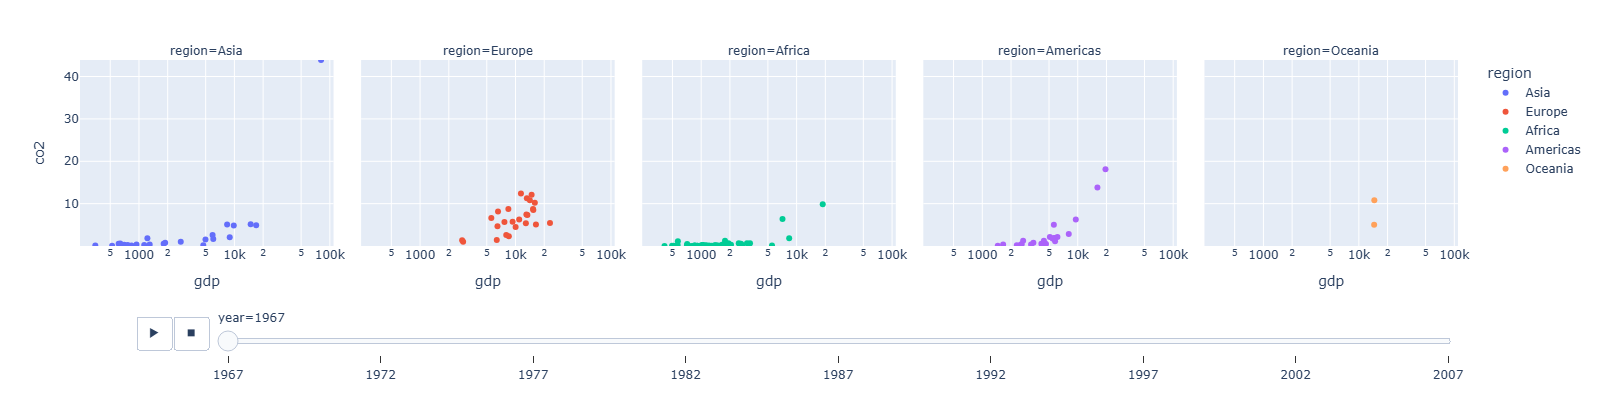

In [15]:
import plotly.express as px

# --- Added the code here ---
fig = px.scatter(data, x="gdp", y="co2", animation_frame="year",
     animation_group="country", color="region", hover_name="country",
     facet_col="region", width=1600, height=400, log_x=True, size_max=45,
     range_x=[xmin,xmax], range_y=[ymin,ymax])
# ---------------------------

fig.show()

In [16]:
# --- Added the code here ---
fig.write_html("co2_gdp_scatter.html")
# ---------------------------

#### Exercise 2 Creating the Interactive Visualization (Sample 2)

In [17]:
import plotly.express as px

In [18]:
df = px.data.gapminder()
df.head(15)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
5,Afghanistan,Asia,1977,38.438,14880372,786.113360,AFG,4
6,Afghanistan,Asia,1982,39.854,12881816,978.011439,AFG,4
7,Afghanistan,Asia,1987,40.822,13867957,852.395945,AFG,4
8,Afghanistan,Asia,1992,41.674,16317921,649.341395,AFG,4
9,Afghanistan,Asia,1997,41.763,22227415,635.341351,AFG,4


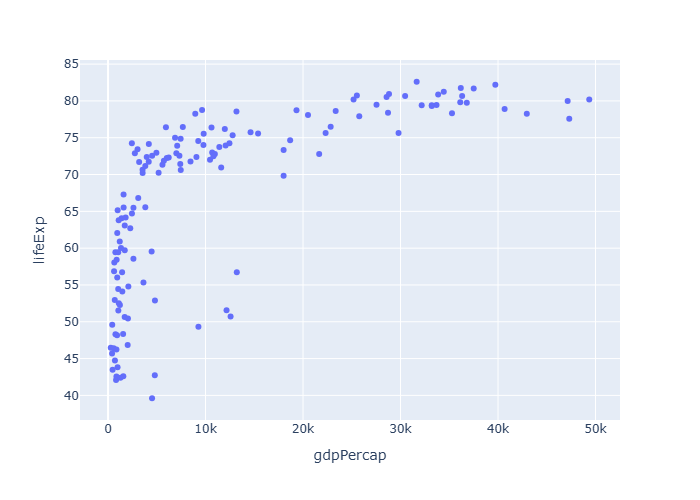

In [19]:
# --- Added the code here ---
fig = px.scatter(
    df.query("year == 2007"),    
    x="gdpPercap",               
    y="lifeExp"                  
)
# ---------------------------

fig.show()

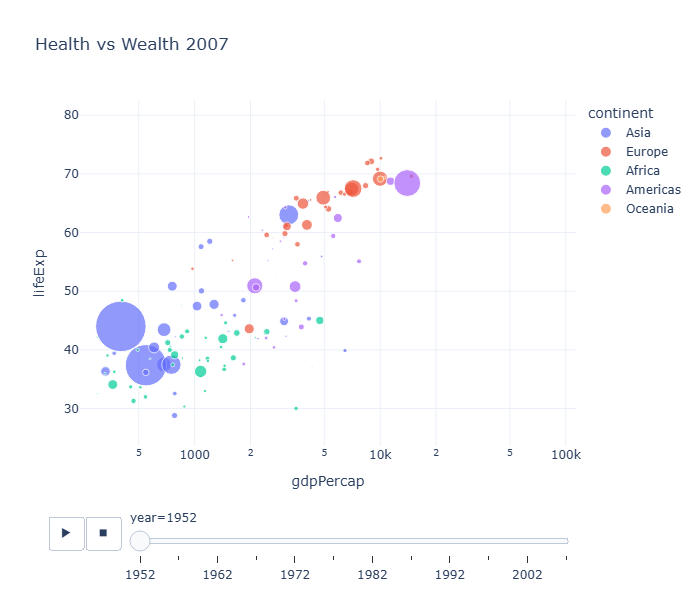

In [20]:
# --- Added the code here ---
fig = px.scatter(
    df,
    template="plotly_white",
    x="gdpPercap",
    y="lifeExp",
    color="continent",
    hover_name="country",
    title="Health vs Wealth 2007",
    height=600,
    animation_frame="year",
    size="pop",
    size_max=55, 
    log_x=True,
    range_x=(df["gdpPercap"].min(), df["gdpPercap"].max()),
    range_y=(df["lifeExp"].min(), df["lifeExp"].max())
)
# ---------------------------

fig.show()

#### Exercise 3 Histogram using Plotly

In [21]:
import plotly.express as px
df = px.data.gapminder()
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


In [22]:
df["year"].unique()

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

In [23]:
df["country"].unique()

<StringArray>
[       'Afghanistan',            'Albania',            'Algeria',
             'Angola',          'Argentina',          'Australia',
            'Austria',            'Bahrain',         'Bangladesh',
            'Belgium',
 ...
             'Uganda',     'United Kingdom',      'United States',
            'Uruguay',          'Venezuela',            'Vietnam',
 'West Bank and Gaza',        'Yemen, Rep.',             'Zambia',
           'Zimbabwe']
Length: 142, dtype: str

In [24]:
df["continent"].unique()

<StringArray>
['Asia', 'Europe', 'Africa', 'Americas', 'Oceania']
Length: 5, dtype: str

In [25]:
df_usa = df.query("iso_alpha == 'USA'")
df_usa

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1608,United States,Americas,1952,68.440,157553000,13990.48208,USA,840
1609,United States,Americas,1957,69.490,171984000,14847.12712,USA,840
1610,United States,Americas,1962,70.210,186538000,16173.14586,USA,840
1611,United States,Americas,1967,70.760,198712000,19530.36557,USA,840
1612,United States,Americas,1972,71.340,209896000,21806.03594,USA,840
1613,United States,Americas,1977,73.380,220239000,24072.63213,USA,840
1614,United States,Americas,1982,74.650,232187835,25009.55914,USA,840
1615,United States,Americas,1987,75.020,242803533,29884.35041,USA,840
1616,United States,Americas,1992,76.090,256894189,32003.93224,USA,840
1617,United States,Americas,1997,76.810,272911760,35767.43303,USA,840


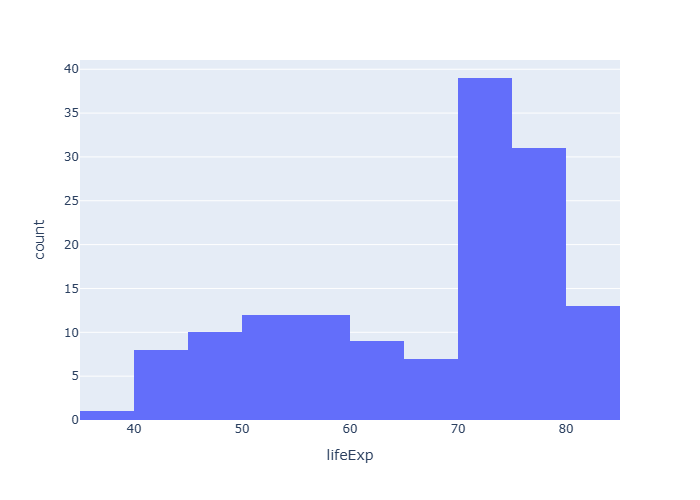

In [26]:
# --- Added the code here ---
fig = px.histogram(df.query("year == 2007"), x="lifeExp")
# ---------------------------

fig.show()

#### Exercise 4 Box Plot using Plotly

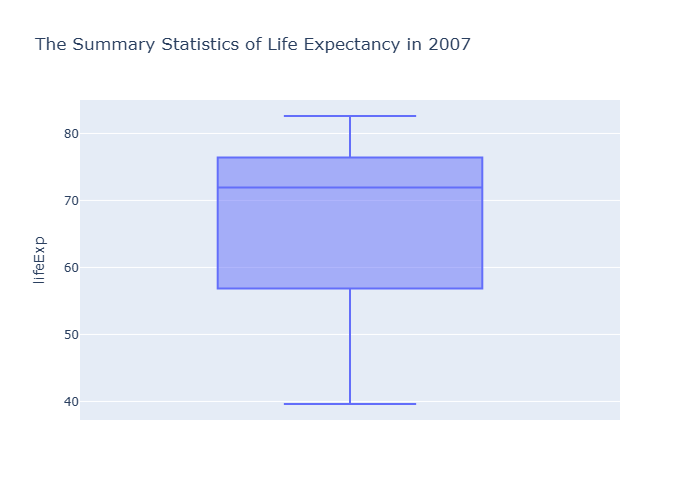

In [27]:
# A vertical boxplot
# --- Added the code here ---
fig = px.box(
    df.query("year == 2007"),
    y="lifeExp",
    title="The Summary Statistics of Life Expectancy in 2007"
)
# ---------------------------

fig.show()

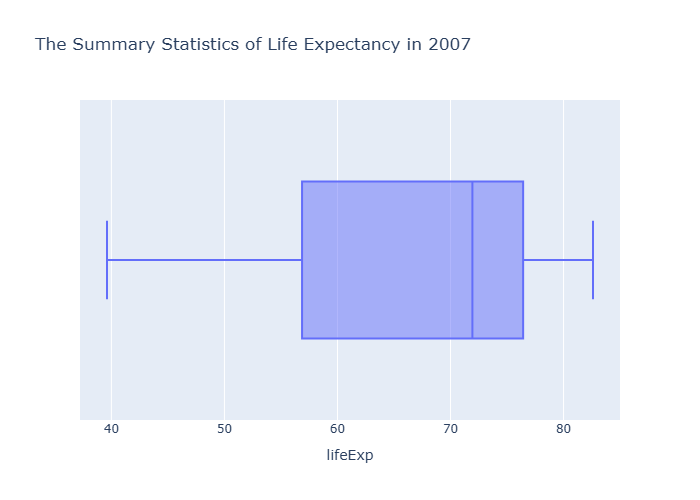

In [28]:
# A horizonal boxplot
# --- Added the code here ---
fig = px.box(
    df.query("year == 2007"),
    x="lifeExp",
    orientation='h',
    title="The Summary Statistics of Life Expectancy in 2007"
)
# ---------------------------

fig.show()

#### Exercise 5 Comparing Two Years

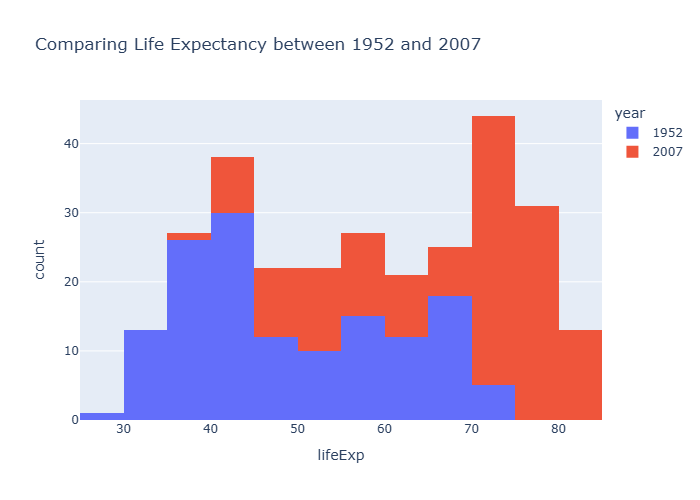

In [29]:
# Compare two years using Histogram
# --- Added the code here ---
fig = px.histogram(
    df.query("year == 1952 or year == 2007"),
    x="lifeExp",
    color="year",
    title="Comparing Life Expectancy between 1952 and 2007"
)
# ---------------------------

fig.show()

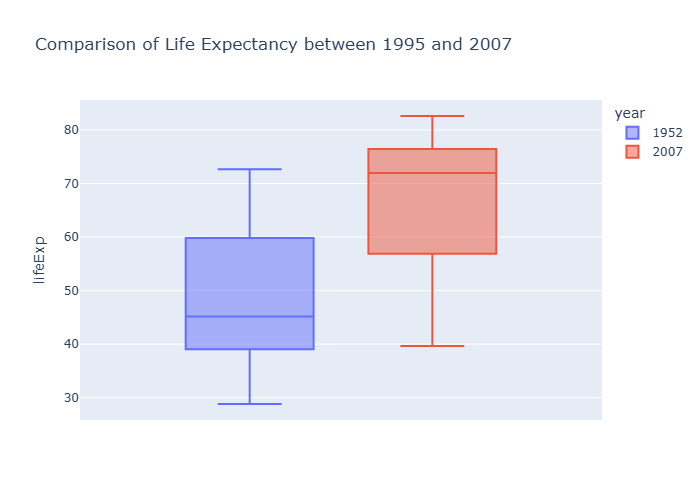

In [30]:
# Compare two years using Boxplot
# --- Added the code here ---
fig = px.box(
    df.query("year == 1952 or year == 2007"),
    y="lifeExp",
    color="year",
    title="Comparison of Life Expectancy between 1995 and 2007"
)
# ---------------------------

fig.show()

#### Exercise 6 Scatter Plot using Plotly

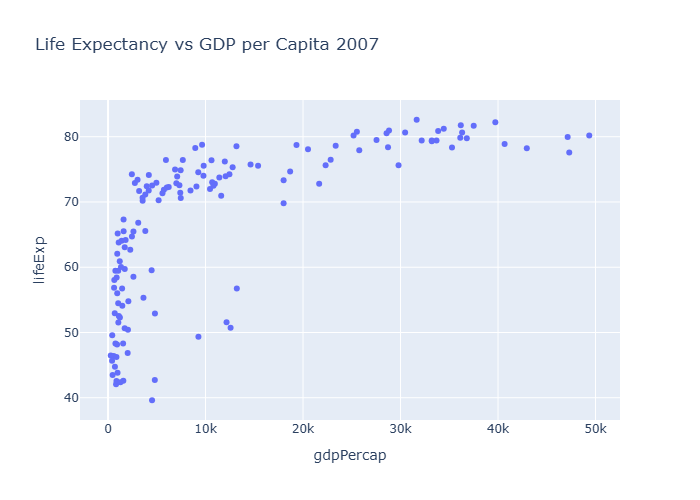

In [31]:
# --- Added the code here ---
fig = px.scatter(
    df.query("year == 2007"),
    x="gdpPercap",
    y="lifeExp",
    title="Life Expectancy vs GDP per Capita 2007"
)
# ---------------------------

fig.show()

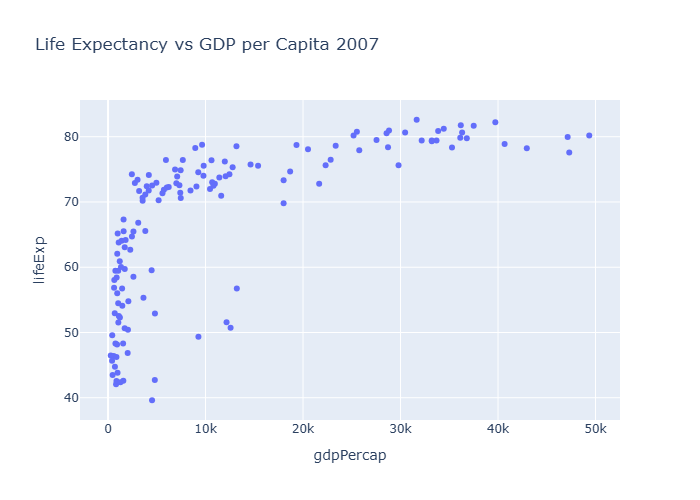

In [32]:
# --- Added the code here ---
fig = px.scatter(
    df.query("year == 2007"),
    x="gdpPercap",
    y="lifeExp",
    hover_name="country",
    title="Life Expectancy vs GDP per Capita 2007"
)
# ---------------------------

fig.show()

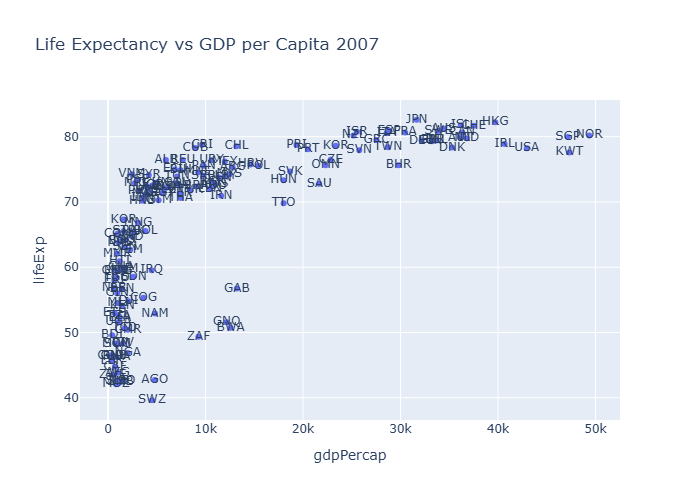

In [33]:
# Scatter plot to show relationship between health and wealth
# --- Added the code here ---
fig = px.scatter(
    df.query("year == 2007"),
    x="gdpPercap",
    y="lifeExp",
    text="iso_alpha",
    hover_name="country",
    title="Life Expectancy vs GDP per Capita 2007"
)
# ---------------------------

fig.show()

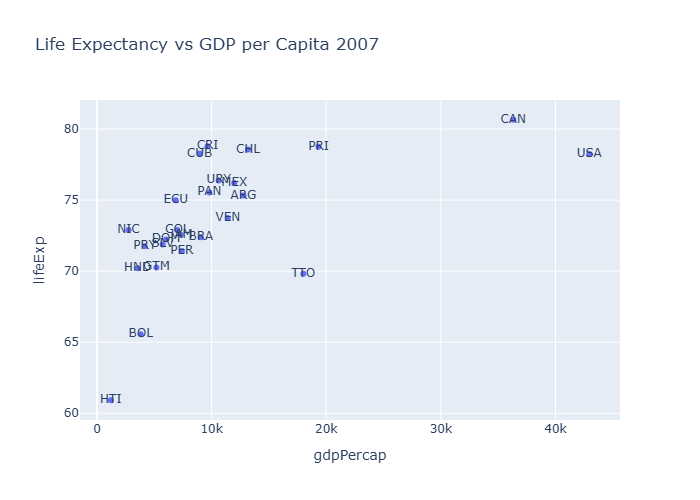

In [34]:
# Scatter plot to show relationship between health and wealth
# --- Added the code here ---
fig = px.scatter(
    df.query("continent == 'Americas' and year == 2007"),
    x="gdpPercap",
    y="lifeExp",
    text="iso_alpha",
    hover_name="country",
    title="Life Expectancy vs GDP per Capita 2007"
)
# ---------------------------

fig.show()

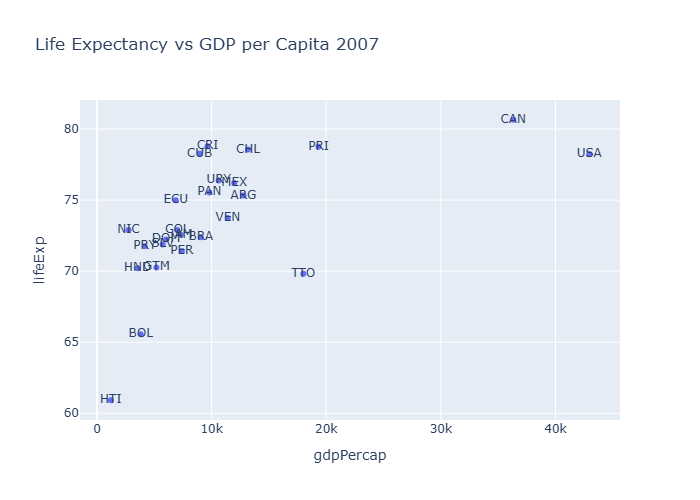

In [35]:
# Scatter plot to show relationship between health and wealth
fig = px.scatter(
    df.query("continent == 'Americas' and year == 2007"),
    x="gdpPercap",
    y="lifeExp",
    text="iso_alpha",
    hover_name="country",
    title="Life Expectancy vs GDP per Capita 2007"
)

# --- Added the code here ---
#
# ---------------------------

fig.show()

#### Exercise 7 Line Chart using Plotly

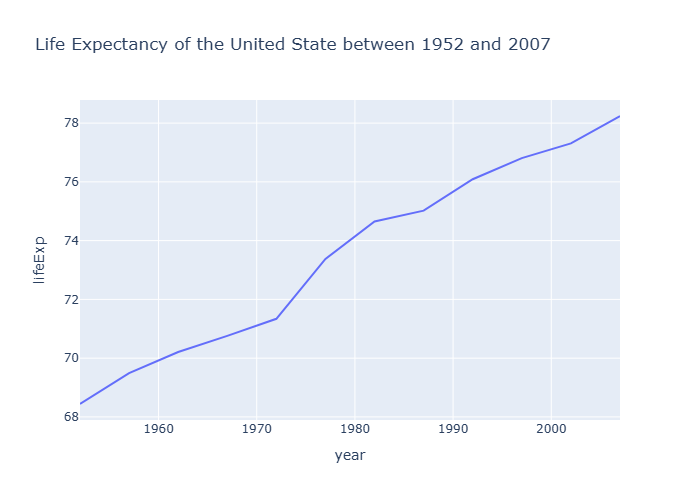

In [36]:
# Line chart
# --- Added the code here ---
fig = px.line(
    data_frame=df.query("iso_alpha == 'USA'"),   
    x="year", 
    y="lifeExp",
    title="Life Expectancy of the United State between 1952 and 2007"
)
# ---------------------------

fig.show()

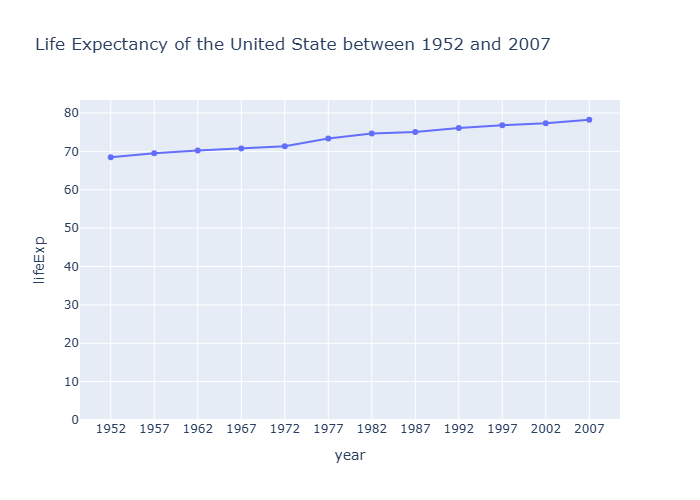

In [37]:
# --- Added the code here ---
fig.update_xaxes(type='category')
fig.update_yaxes(rangemode="tozero")
fig.update_traces(mode='markers+lines')
# ---------------------------

fig.show()

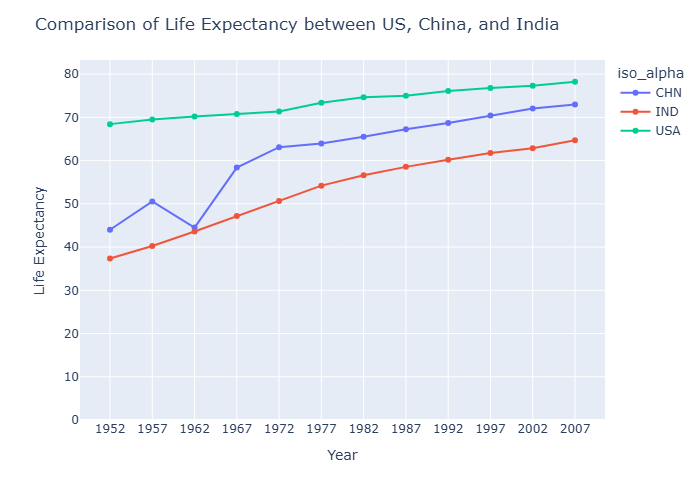

In [38]:
# --- Added the code here ---
df_usa_chn_ind = df[df["iso_alpha"].isin(["USA", "CHN", "IND"])]
# ---------------------------

fig = px.line(df_usa_chn_ind, x="year", y="lifeExp", color="iso_alpha")

fig.update_traces(mode='markers+lines')
fig.update_xaxes(type='category', title="Year")
fig.update_yaxes(rangemode="tozero", title="Life Expectancy")
fig.update_layout(title="Comparison of Life Expectancy between US, China, and India")
fig.show()

#### Exercise 8 A “Hello World” Chart

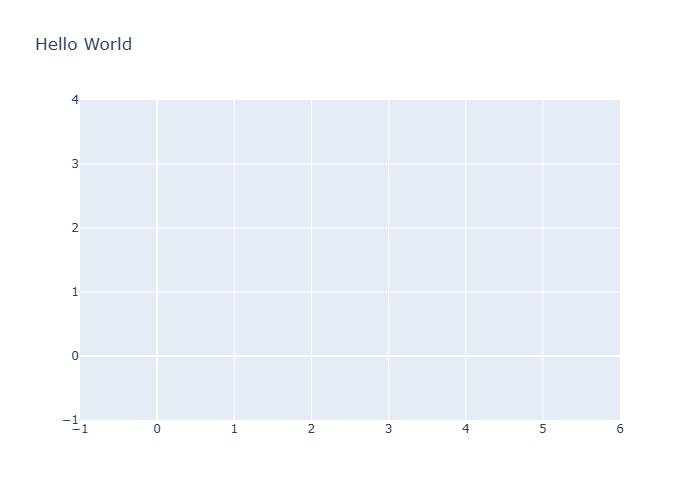

In [39]:
import numpy as np                  # We use numpy to generate some sample data for ploting
import plotly.graph_objects as go   # graph_opjects package is the core of plotly
import plotly.io as pio
import plotly

fig = go.Figure()

# --- Added the code here ---
fig.update_layout(title="Hello World")
# ---------------------------

fig.show()

#### Exercise 9 A Boxplot of Ages of Some Men

In [40]:
# Here, we use Numpy to generate a list of random numbers 
# to represent the ages for a group of men.

male_ages = np.random.randint(low=1, high=101, size=20)   
# 20 random integers between 1 and 101 excluding 101.

print(male_ages)

[48 26 66 47 46 24  8 39  9 96 64 12 14 34 72 55 71 46 37 26]


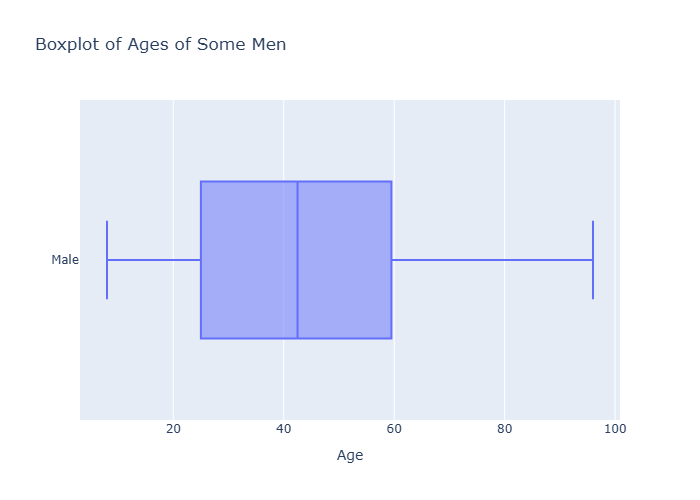

In [41]:
# --- Added the code here ---
trace_0 = go.Box(   
    x=male_ages,    
    name="Male"     
)
# ---------------------------

fig = go.Figure()
fig.add_trace(trace_0)

fig.update_layout(
    title="Boxplot of Ages of Some Men",
    xaxis={"title":"Age"}         # This is equivalent to xaxis_title="Age"
)

fig.show()

#### Exercise 10 A Boxplot of Ages of Some Men and Women

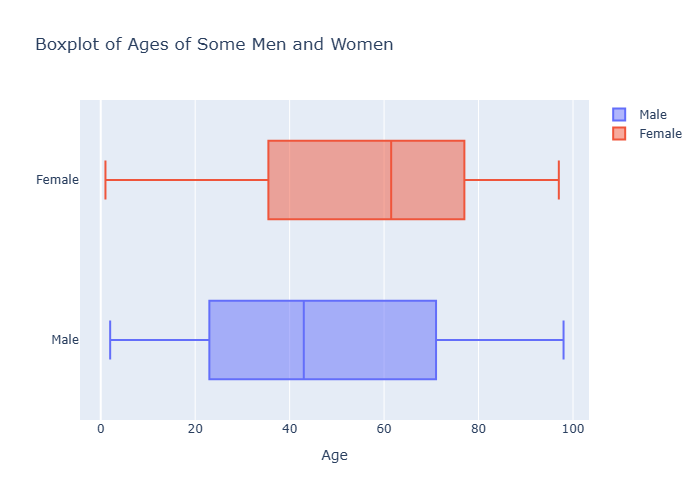

In [42]:
male_ages = np.random.randint(low=1, high=100, size=20)

# --- Added the code here ---
trace_0 = go.Box(   
    x=male_ages,    
    name="Male"   
)
# ---------------------------

female_ages = np.random.randint(low=1, high=100, size=20)

# --- Added the code here ---
trace_1 = go.Box(   
    x=female_ages,    
    name="Female"    
)
# ---------------------------

fig = go.Figure()
fig.add_trace(trace_0)
fig.add_trace(trace_1)

fig.update_layout(
    title="Boxplot of Ages of Some Men and Women",
    xaxis={"title":"Age"},
    showlegend=True             # The legend can be shown or hidden
)

fig.show()

#### Exercise 11 Linear Regression: Development vs Culture

In [43]:
x= np.random.randint(low=1, high=10, size=100)   
# random integer between 1 and 10 (10 is not included)

y = x * 2 + 1

print(x[:10])      # print the first 10 x's
print(y[:10])      # print the last 10 y's

[4 6 3 8 8 5 5 2 7 4]
[ 9 13  7 17 17 11 11  5 15  9]


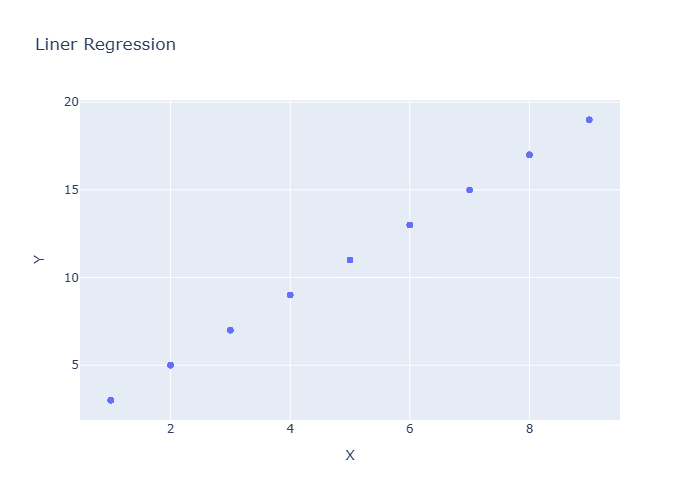

In [44]:
fig = go.Figure()

# --- Added the code here ---
trace_0 = {
    "x":x,
    "y":y,
    "type":"scatter",
    "mode":"markers",
    "name":"Observed"
}
# ---------------------------

fig.add_trace(trace_0)

fig.update_layout(
    title="Liner Regression",
    xaxis={"title":"X"},
    yaxis={"title":"Y"}
)

fig.show()

In [45]:
error = np.random.normal(loc=0, scale=1, size=100)

y = x * 2 + 1 + error

print(x[:10])      # print the first 10 x's
print(y[:10])      # print the last 10 y's

[4 6 3 8 8 5 5 2 7 4]
[ 8.39903352 12.11520694  7.82023284 17.78925845 17.2912183  10.19272494
 12.33341581  5.49089869 15.16659341 10.03600993]


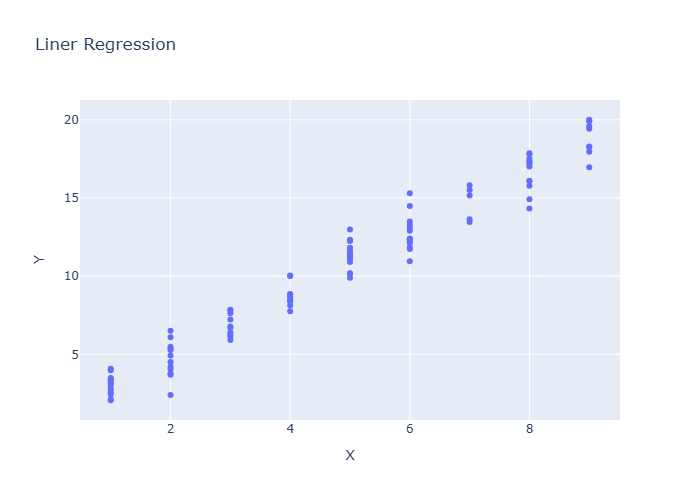

In [46]:
fig = go.Figure()

# --- Added the code here ---
trace_0 = {
    "x":x,
    "y":y,
    "type":"scatter",
    "mode":"markers",
    "name":"Observed"
}
# ---------------------------

fig.add_trace(trace_0)

fig.update_layout(
    title="Liner Regression",
    xaxis={"title":"X"},
    yaxis={"title":"Y"}
)

fig.show()

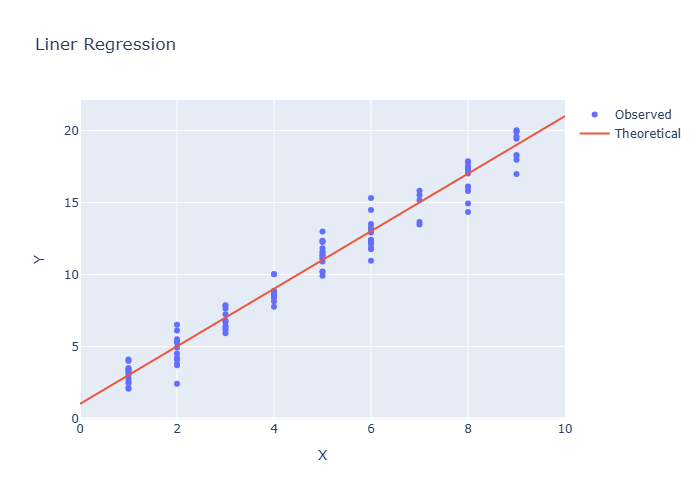

In [47]:
# --- Added the code here ---
trace_1 = {
    "x":[0,10],
    "y":[1,21],
    "type":"scatter",
    "mode":"lines",
    "name":"Theoretical"
}
# ---------------------------

fig.add_trace(trace_1)
fig.show()

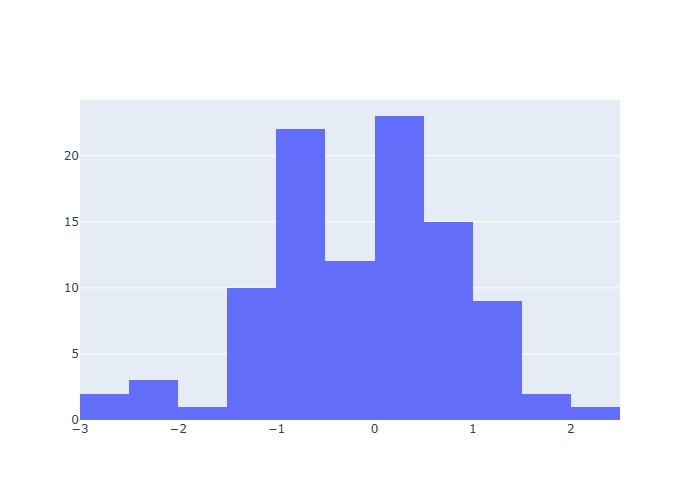

In [48]:
fig_error = go.Figure()

# --- Added the code here ---
trace_0 = {
    "x":error,
    "type":"histogram"
}
# ---------------------------

fig_error.add_trace(trace_0)
fig_error.show()

#### Exercise 12 Violin plots in Plotly

In [49]:
import pandas as pd
import plotly.express as px

diamonds = pd.read_csv("diamonds.csv")

diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


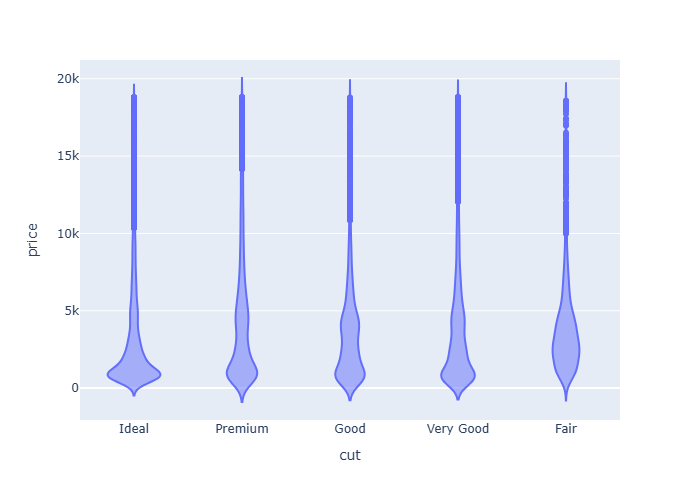

In [50]:
# --- Added the code here ---
fig = px.violin(diamonds, x="cut", y="price")
# ---------------------------

fig.show()

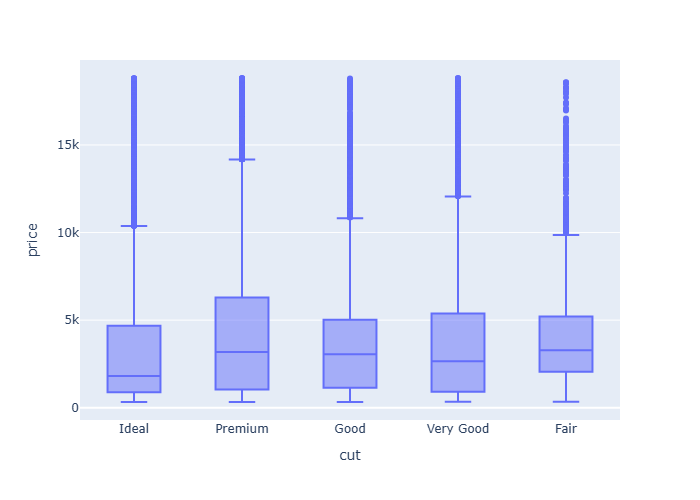

In [51]:
# --- Added the code here ---
fig = px.box(diamonds, x="cut", y="price")
# ---------------------------

fig.show()

#### Exercise 13 Heatmaps using Plotly

In [52]:
import pandas as pd
import plotly.express as px

diamonds = pd.read_csv("diamonds.csv")
# Select only numeric columns for correlation calculation
diamonds = diamonds.select_dtypes(include=[np.number])

diamonds

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74


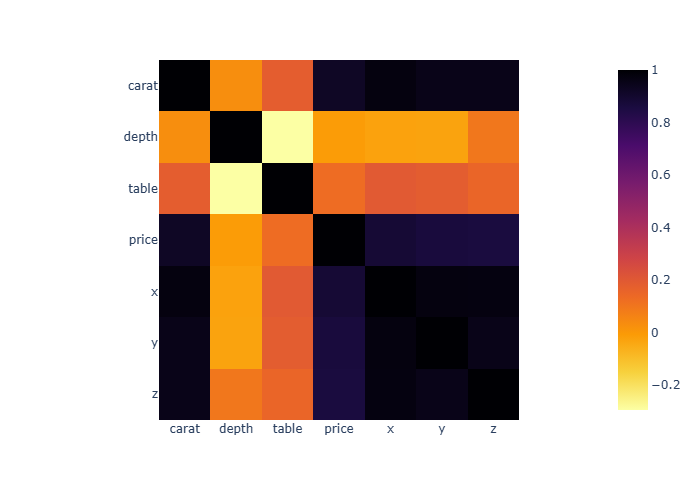

In [53]:
import plotly.express as px

# Create heatmap using Plotly Express
# --- Added the code here ---
fig = px.imshow(
  diamonds.corr(),
  color_continuous_scale="Inferno_r",
)
# ---------------------------

# Show plot
fig.show()

#### Exercise 14 Pie Chart using Plotly

In [54]:
import plotly.express as px

df = px.data.gapminder().query("year == 2007").query("continent == 'Europe'")
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
83,Austria,Europe,2007,79.829,8199783,36126.492700,AUT,40
119,Belgium,Europe,2007,79.441,10392226,33692.605080,BEL,56
155,Bosnia and Herzegovina,Europe,2007,74.852,4552198,7446.298803,BIH,70
191,Bulgaria,Europe,2007,73.005,7322858,10680.792820,BGR,100
383,Croatia,Europe,2007,75.748,4493312,14619.222720,HRV,191
407,Czech Republic,Europe,2007,76.486,10228744,22833.308510,CZE,203
419,Denmark,Europe,2007,78.332,5468120,35278.418740,DNK,208
527,Finland,Europe,2007,79.313,5238460,33207.084400,FIN,246
539,France,Europe,2007,80.657,61083916,30470.016700,FRA,250


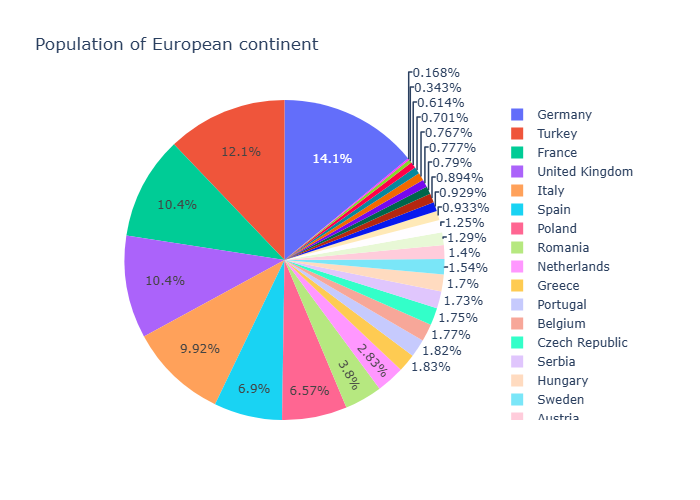

In [55]:
df.loc[df['pop'] < 2.e6, 'country'] = 'Other countries' # Represent only large countries

# --- Added the code here ---
fig = px.pie(df, values='pop', names='country', title='Population of European continent')
# ---------------------------

fig.show()

2.e6 is same as 2 x 10^6 

#### Exercise 15 Pie chart with repeated labels

In [56]:
import plotly.express as px

df = px.data.tips()
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


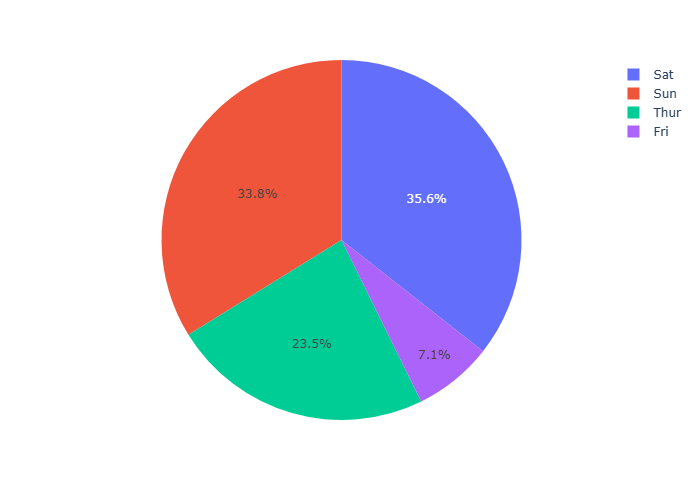

In [57]:
# --- Added the code here ---
fig = px.pie(df, values='tip', names='day')
# ---------------------------

fig.show()

#### Exercise 16 Pulling sectors out from the center

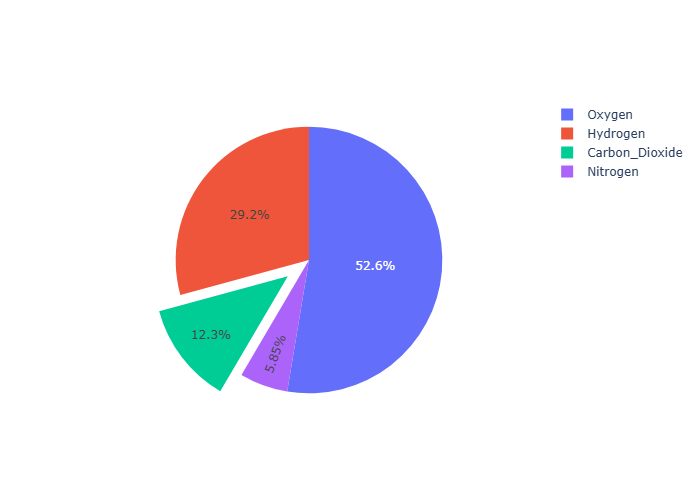

In [58]:
import plotly.graph_objects as go

labels = ['Oxygen','Hydrogen','Carbon_Dioxide','Nitrogen']
values = [4500, 2500, 1053, 500]

# pull is given as a fraction of the pie radius
# --- Added the code here ---
fig = go.Figure(data=[go.Pie(labels=labels, values=values, pull=[0, 0, 0.2, 0])])
# ---------------------------

fig.show()

#### Exercise 17 Customizing plots in Plotly

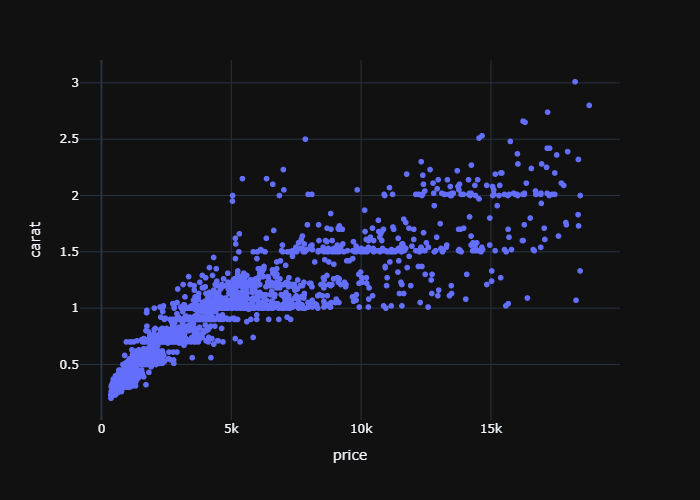

In [59]:
import pandas as pd
import plotly.express as px

diamonds = pd.read_csv("diamonds.csv")

sample = diamonds.sample(3000)

# --- Added the code here ---
fig = px.scatter(
  sample, x="price", y="carat", template="plotly_dark"
)
# ---------------------------

fig.show()

In [60]:
import plotly.io as pio
pio.templates

Templates configuration
-----------------------
    Default template: 'plotly'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']

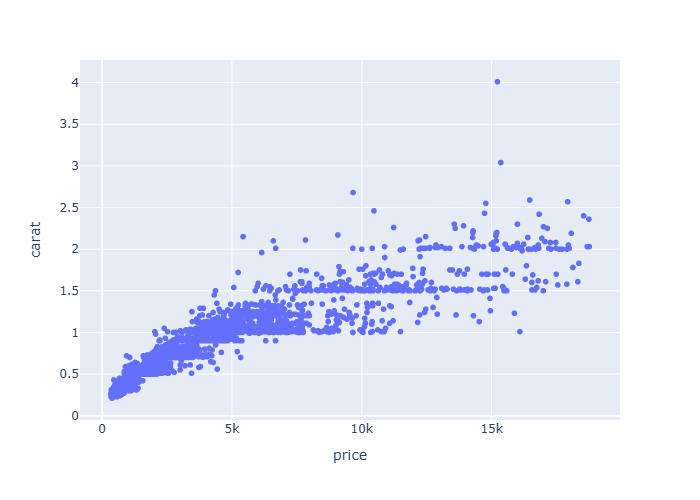

In [61]:
sample = diamonds.sample(3000)

# --- Added the code here ---
fig = px.scatter(sample, x="price", y="carat")
# ---------------------------

fig.show()

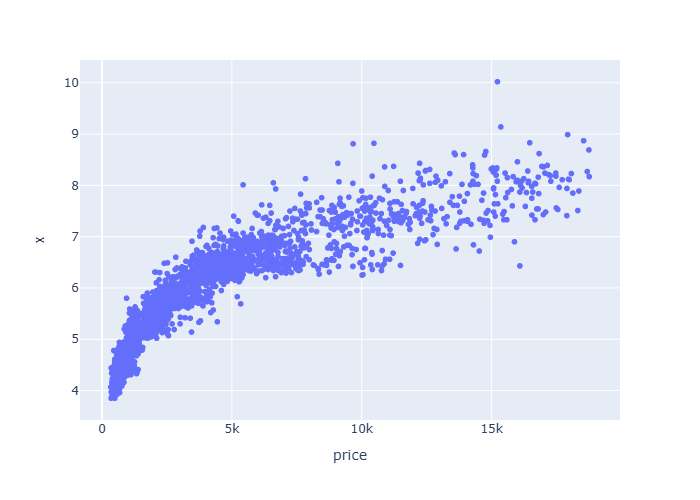

In [62]:
# --- Added the code here ---
fig = px.scatter(sample, x="price", y="x")
# ---------------------------

fig.show()

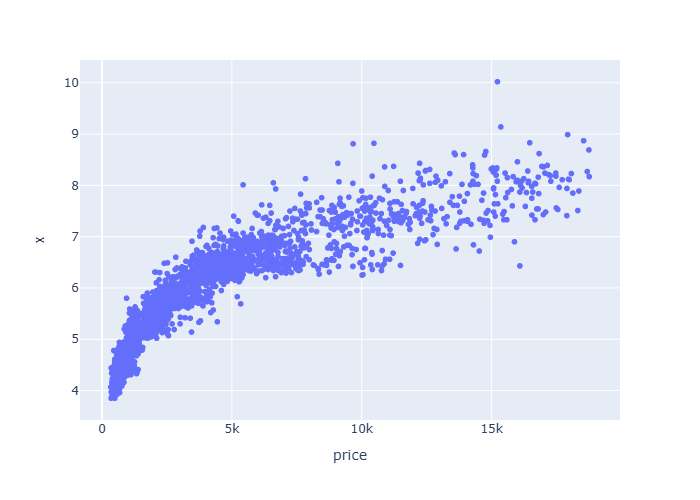

In [63]:
# --- Added the code here ---
fig = px.scatter(
  sample, x="price", y="x"
)
# ---------------------------

fig.show()

---

#### **Revised Date: January 13, 2026**